<div style="text-align:center;">
  <h1 size=10>
    <b>DEEP LEARNING PROJECT</b><br>
    <b>WikiArt Painter Classification</b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group 18**
- Bárbara Franco (20250388)
- Catarina Mendinhas (20250422)
- Guilherme Silva (20221910)  
- Maria Carvalho (20221953)
- Maria Miguel Fonseca (20250380)

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Approach Overview](#1)
- [2. Set up & Imports](#2)
- [3. Load Dataset](#3)
- [4. Class Weights](#4)
- [5. Data Preprocessing](#5)
- [6. Class Imbalance Strategy Comparison](#6)
- [7. Augmentation Experiments](#7)
    - [7.1 Experiment 1](#7_1)
    - [7.2 Experiment 2](#7_2)
    - [7.3 Experiment 3](#7_3)
    - [7.4 Experiment 4](#7_4)
    - [7.5 Experiment 5](#7_5)
    - [7.6 Experiment 6](#7_6)

# <font color='#2f94d7' size=6>**1. Approach Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

This notebook contains the additional experiments performed during the development of the project. These experiments helped us explore different design choices and refine the final modeling pipeline.

The analyses presented here were used to guide our decisions but are not required for the main modeling workflow. For this reason, they are documented separately from the primary modeling notebook.


# <font color='#2f94d7' size=6>**2. Set up & Imports**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT LIBRARIES
import os
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from PIL import Image
import cv2
import pandas as pd

from pathlib import Path
import zipfile


import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import EfficientNetB0, VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shutil
import seaborn as sns

import gc
from keras.applications import VGG16, ResNet50V2, ConvNeXtTiny, EfficientNetB3, EfficientNetV2S


# Import .py files
import sys
sys.path.append('/content/drive/MyDrive/source')
#from source.functions import *
from functions import *

In [ ]:
# Unzip config
ZIP_PATH   = Path('/content/drive/MyDrive/wikiart_split.zip')  # ajusta se necessário
EXTRACT_TO = Path('/content/wikiart_split')                     # disco local do Colab

if not EXTRACT_TO.exists():
    print('Extracting ZIP... (may take 1–2 minutes the first time)')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_TO.parent)
    print('Extraction completed!')
else:
    print('Folder already exists, skipping extraction.')

Pasta já existe, a saltar extração.


In [ ]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# GENERAL CONFIGURATION
AUTOTUNE    = tf.data.AUTOTUNE
output_dir = "figures"

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')

Keras  : 3.13.2
TF     : 2.19.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# <font color='#2f94d7' size=6>**3. Load Dataset**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [ ]:
# DATASET CONFIGURATION
IMG_SIZE    = (512, 512)   # Initial image size (can be adapted later for modeling)
NUM_CLASSES = 23
BATCH_SIZE  = 32

SPLIT_DIR      = Path('wikiart_split')
train_dir_path = SPLIT_DIR / 'train'
val_dir_path   = SPLIT_DIR / 'val'
test_dir_path  = SPLIT_DIR / 'test'

In [ ]:
# LOAD DATASETS FROM THE SPLIT FOLDERS
# image_dataset_from_directory infers labels from subfolder names,
# guaranteeing consistent class_names order across machines.

train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir_path,
    label_mode='int', # integer labels for multi-class classification with class weights
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle = True,
    verbose=False
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    val_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir_path,
    label_mode='int',
    batch_size=None,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

class_names = train_ds_raw.class_names

In [ ]:
print(f"Class names: {class_names}")

# Check if labels are correctly inferred (int)
image, label = next(iter(train_ds_raw))
print("Image shape:", image.shape)   # (224, 224, 3)
print("Label:", label.numpy())
print("Class:", class_names[int(label)])

Class names: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
Image shape: (512, 512, 3)
Label: 15
Class: Pablo_Picasso


# <font color='#2f94d7' size=6>**4. Class Weights**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

In [ ]:
# Compute class weights to handle class imbalance

# Extract labels from training dataset (convert one-hot → class index)
train_labels_flat = np.array([
    y.numpy() for _, y in train_ds_raw
])

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_flat
)

# Convert to dictionary format required by Keras
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

# Display classes with highest weights (rarest classes)
print("Class weights (top 5 heaviest):")
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)

for idx, w in sorted_cw[:5]:
    print(f"  {class_names[idx]:<10}: {w:.3f}")

Class weights (top 5 heaviest):
  Salvador_Dali: 1.726
  Raphael_Kirchner: 1.599
  Ivan_Shishkin: 1.593
  Ilya_Repin: 1.531
  Childe_Hassam: 1.515


As expected, artists with fewer paintings receive higher class weights. This ensures that misclassifications on these underrepresented classes are penalized more during training, helping to reduce the impact of class imbalance.

# <font color='#2f94d7' size=6>**5. Data Preprocessing**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [ ]:
# DEFINE AND APPLY DATA AUGMENTATION
base_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),       # around ±10°
    layers.RandomTranslation(0.03, 0.03),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="base_augmentation")

train_aug = (train_ds_raw
    .shuffle(10000, seed=SEED)
    .map(lambda x, y: (base_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))
# train_aug is not a dataset that is stored in memory, but a transformation pipeline applied on-the-fly to the training dataset.
# every time train_aug is iterated over, the base_augmentation transformations are applied to the images in train_ds_raw in a randomized manner, creating augmented versions of the images on-the-fly during training.
# loads 1000 samples into a shuffle buffer, shuffles them, and then applies the augmentation transformations to each batch of images as they are fed into the model during training.

In [ ]:
# RESIZE DATASETS TO DIFFERENT SIZES
# we create separate resized datasets for each image size we want to experiment with during modeling.
train_224, val_224 = build_resized_ds(train_aug, val_ds_raw, 224, AUTOTUNE)
train_300, val_300 = build_resized_ds(train_aug, val_ds_raw, 300, AUTOTUNE)
train_384, val_384 = build_resized_ds(train_aug, val_ds_raw, 384, AUTOTUNE)
train_512 = train_aug
val_512 = val_ds_raw


# <font color='#2f94d7' size=6>**6. Class Imbalance Strategy Comparison**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

The WikiArt dataset has a moderate class imbalance (~3.9:1 ratio between Van Gogh and Salvador Dali).
Although not extreme, this is sufficient to bias the model towards majority classes, which macro F1 directly penalises.

We compare four strategies, keeping all other variables fixed (EfficientNetB0, same head, same callbacks):

| Config | Loss | Class Weights | Oversampling | Rationale |
|---|---|---|---|---|
| *Baseline* | Sparse CE | ✗ | ✗ | Reference point — no imbalance correction |
| *Class Weights* | Sparse CE | ✓ | ✗ | Penalise minority class errors proportionally |
| *Focal Loss* | Focal (γ=2) | ✗ | ✗ | Dynamic focus on hard/ambiguous examples — no data modification |
| *Oversampling 2:1* | Sparse CE | ✗ | ✓ | Reduce max/min ratio from 3.9:1 to ~2:1 by repeating minority samples |

*Why not augmentation with oversampling?* For paintings, discriminative features (palette, brushstroke direction, composition) are precisely what aggressive augmentations destroy. Conservative augmentations already applied in the pipeline provide sufficient variety.

*Why not 1:1 oversampling?* Paintings have structurally lower intra-class variance than natural photos (330 Dali paintings are more similar to each other than 330 random cat photos). Full equalisation risks memorisation of minority class samples.

*Comparison criterion*: ⁠ val_macro_f1 ⁠ at the best epoch (lowest ⁠ val_loss ⁠). Val loss is NOT comparable across Focal Loss vs CE configs — macro F1 is the only valid cross-config metric.

In [ ]:
# Class Imbalance Experiment Configuration
IMBALANCE_BACKBONE     = 'EfficientNetB0'  # fast proxy, ranking holds across backbones
OVERSAMPLE_TARGET_RATIO = 2.0              # reduce 3.9:1, around 2:1 max/min ratio
FOCAL_GAMMA            = 2.0              # standard value from Lin et al. 2017

# Re-use Phase 1 training hyperparameters for consistency
# PHASE1_EPOCHS, PHASE1_LR, ES_PATIENCE_P1, etc. already defined above

In [ ]:
# Build oversampled dataset
# Repeats minority-class samples until max_count / min_count ≈ target_ratio.
# Operates on an unbatched, augmented tf.data.Dataset with integer labels.
def build_oversampled_ds(base_ds, train_labels, target_ratio, seed=SEED):
    from collections import Counter
    counts      = Counter(train_labels.tolist())
    max_count   = max(counts.values())
    target_min  = int(max_count / target_ratio)

    oversampled = base_ds
    added = {}

    for class_idx, count in sorted(counts.items()):
        if count < target_min:
            extra_needed   = target_min - count
            repeat_factor  = int(np.ceil(extra_needed / count))

            # Default-arg trick captures class_idx by value (avoids loop closure bug)
            class_ds = base_ds.filter(lambda x, y, ci=class_idx: tf.equal(y, ci))
            extra_ds = class_ds.repeat(repeat_factor).take(extra_needed)
            oversampled = oversampled.concatenate(extra_ds)
            added[class_names[class_idx]] = extra_needed

    print(f'Oversampling summary (target ratio {target_ratio}:1):')
    for artist, n in sorted(added.items(), key=lambda x: -x[1]):
        print(f'  {artist:<30} +{n} samples')

    return oversampled.shuffle(buffer_size=10000, seed=seed)


# Convert integer labels to one-hot (for Focal Loss)
def to_one_hot_ds(ds):
    """Maps integer labels → one-hot vectors. Apply before apply_preprocess_ds."""
    return ds.map(
        lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)),
        num_parallel_calls=AUTOTUNE
    )

In [ ]:
# Pre-build oversampled dataset (done once, reused in the loop)
imb_cfg = BACKBONE_CONFIGS[IMBALANCE_BACKBONE]

# Base unbatched dataset at EfficientNetB0 resolution (already augmented)
train_base_224 = imb_cfg['train_ds']  # unbatched, integer labels
val_base_224   = imb_cfg['val_ds']    # unbatched, integer labels

# Oversampled variant
train_oversampled_224 = build_oversampled_ds(
    train_base_224, train_labels_flat, OVERSAMPLE_TARGET_RATIO
)

# One-hot variants for Focal Loss (train + val)
train_onehot_224 = to_one_hot_ds(train_base_224)
val_onehot_224   = to_one_hot_ds(val_base_224)

print('\nDataset variants ready.')

In [ ]:
# Imbalance Strategy Comparison Loop
# All configs use EfficientNetB0 with the same head and callbacks.
# Only the loss function, class weights, and dataset change.

IMBALANCE_CONFIGS = {
    'Baseline': {
        'loss':             'sparse_categorical_crossentropy',
        'use_class_weight': False,
        'train_ds':         train_base_224,
        'val_ds':           val_base_224,
        'sparse':           True,
    },
    'Class_Weights': {
        'loss':             'sparse_categorical_crossentropy',
        'use_class_weight': True,
        'train_ds':         train_base_224,
        'val_ds':           val_base_224,
        'sparse':           True,
    },
    'Focal_Loss': {
        # CategoricalFocalCrossentropy available natively from TF/Keras >= 2.12
        # gamma=2.0 is the standard value from Lin et al. (2017)
        # Requires one-hot labels — class_weight not compatible with one-hot
        'loss':             keras.losses.CategoricalFocalCrossentropy(gamma=FOCAL_GAMMA),
        'use_class_weight': False,
        'train_ds':         train_onehot_224,
        'val_ds':           val_onehot_224,
        'sparse':           False,  # uses TopKCategoricalAccuracy
    },
    'Oversampling_2to1': {
        'loss':             'sparse_categorical_crossentropy',
        'use_class_weight': False,
        'train_ds':         train_oversampled_224,
        'val_ds':           val_base_224,
        'sparse':           True,
    },
}

imbalance_results = {}

for config_name, config in IMBALANCE_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  {IMBALANCE_BACKBONE} | Strategy: {config_name}')
    print(f'{"="*60}')

    model, bb = build_base_model(IMBALANCE_BACKBONE)

    train_ds, val_ds = apply_preprocess_ds(
        train_resized=config['train_ds'],
        val_resized=config['val_ds'],
        preprocess_fn=imb_cfg['preprocess'],
        batch_size=BATCH_SIZE
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
        loss=config['loss'],
        metrics=make_metrics(sparse=config['sparse'])
    )

    fit_kwargs = dict(
        epochs=PHASE1_EPOCHS,
        validation_data=val_ds,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=ES_PATIENCE_P1,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=LR_FACTOR_P1,
                patience=LR_PATIENCE_P1,
                min_lr=LR_MIN_P1,
                verbose=1
            ),
        ],
        verbose=1
    )

    # Only pass class_weight when using sparse labels (incompatible with one-hot)
    if config['use_class_weight']:
        fit_kwargs['class_weight'] = class_weight_dict

    hist = model.fit(train_ds, **fit_kwargs)

    best_epoch = np.argmin(hist.history['val_loss'])

    imbalance_results[config_name] = {
        'best_train_f1': hist.history['macro_f1'][best_epoch],
        'best_val_f1':   hist.history['val_macro_f1'][best_epoch],
        'best_val_top3': hist.history['val_top3_accuracy'][best_epoch],
        'min_val_loss':  hist.history['val_loss'][best_epoch],
        'history':       hist.history,
    }

    overfit_gap = imbalance_results[config_name]['best_train_f1'] - imbalance_results[config_name]['best_val_f1']
    print(f'  Overfitting gap (train F1 - val F1) : {overfit_gap:.4f}')
    print(f'  Best val macro F1                   : {imbalance_results[config_name]["best_val_f1"]:.4f}')
    print(f'  Best val top-3                      : {imbalance_results[config_name]["best_val_top3"]:.4f}')
    print(f'  Min val loss                        : {imbalance_results[config_name]["min_val_loss"]:.4f}')

    del model, bb
    keras.backend.clear_session()
    gc.collect()

print(f'\n{"="*60}')
print(f'  Class imbalance comparison complete')
print(f'{"="*60}')

In [ ]:
# Results Summary Table
print(f'\nClass imbalance strategy comparison — {IMBALANCE_BACKBONE}\n')
print(f'{"Strategy":<22} {"Val Macro F1":>14} {"Val Top-3":>12} {"Overfit Gap":>13}')
print('-' * 63)

for name, r in sorted(imbalance_results.items(),
                       key=lambda x: x[1]['best_val_f1'], reverse=True):
    gap = r['best_train_f1'] - r['best_val_f1']
    print(f'{name:<22} {r["best_val_f1"]:>14.4f} '
          f'{r["best_val_top3"]:>12.4f} {gap:>13.4f}')

In [ ]:
# Comparison Plots
# NOTE: val_loss curves are NOT comparable across Focal Loss vs CE configs
# (different loss scales). Use val_macro_f1 for cross-config comparison.

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f'Class Imbalance Strategy Comparison — {IMBALANCE_BACKBONE}', fontsize=14)

for name, r in imbalance_results.items():
    epochs = range(1, len(r['history']['val_macro_f1']) + 1)

    axes[0].plot(epochs, r['history']['val_macro_f1'], label=name, linewidth=2)
    axes[1].plot(epochs, r['history']['val_loss'],     label=name, linewidth=2,
                 linestyle='--' if name == 'Focal_Loss' else '-')  # dashed = different scale

    gap = [tr - va for tr, va in zip(r['history']['macro_f1'],
                                      r['history']['val_macro_f1'])]
    axes[2].plot(epochs, gap, label=name, linewidth=2)

axes[0].set_title('Validation Macro F1 by Strategy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Macro F1')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Strategy\n(Focal Loss on different scale — dashed)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Overfitting Gap (Train − Val F1)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Gap')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'imbalance_strategy_comparison.png'), dpi=150)
plt.show()

**Interpretation guide**:
- The primary criterion is `val_macro_f1` — the only metric comparable across all configs.
- A high overfitting gap with Oversampling suggests memorisation of repeated minority samples.
- If Focal Loss leads with similar or lower overfit gap, it is the recommended strategy to carry forward into Phase 2 and subsequent experiments.
- The winning strategy from this section is used in all following experiments (head comparison, augmentation study, Phase 2).

# <font color='#2f94d7' size=6>**7. Augmentation Experiments**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

In [ ]:
TOP2_BACKBONES = ['EfficientNetV2S', 'ConvNeXtTiny']

UNFREEZE_CONFIG = {
    'EfficientNetV2S': 30,
    'ConvNeXtTiny': 50
}

In [ ]:
# PHASE 1 CONFIGURATION - INITIAL COMPARISON OF BACKBONES WITH FROZEN WEIGHTS AND SIMPLE HEAD
PHASE1_CONFIG = {
  'PHASE1_EPOCHS'    : 20,
  'PHASE1_LR'        : 1e-3,
  'ES_PATIENCE_P1'   : 7,
  'LR_FACTOR_P1'     : 0.3,
  'LR_PATIENCE_P1'   : 4,
  'LR_MIN_P1'        : 1e-6}

In [ ]:
# CONFIGURATIONS FOR PHASE 2 - FINE-TUNING THE BEST BACKBONE WITH UNFROZEN WEIGHTS AND OPTIMISED HEAD
PHASE2_CONFIG = {
  'PHASE2_LR'         : 1e-5 ,
  'PHASE2_EPOCHS'     : 30  ,
  'ES_PATIENCE_P2'    : 6,
  'LR_FACTOR_P2'      : 0.3,
  'LR_PATIENCE_P2'    : 3,
  'LR_MIN_P2'         : 1e-7}

## <font color='#2f94d7' size=6>**7.1 Experiment 1**</font> <a class="anchor" id="7_1"></a>

[Back to TOC](#toc)

In [ ]:
# Augmentation configs
AUGMENTATION_CONFIGS = {
    'baseline': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_baseline'),

    'geometric': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.10),
    ], name='aug_geometric'),

    'color': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(0.20),
        layers.RandomContrast(0.20),
    ], name='aug_color'),

    'balanced': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.04),
        layers.RandomTranslation(0.04, 0.04),
        layers.RandomZoom(0.08),
        layers.RandomBrightness(0.12),
        layers.RandomContrast(0.12),
    ], name='aug_balanced')
}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : baseline
Unfreeze     : 30
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 270s 418ms/step - loss: 1.7594 - macro_f1: 0.4874 - top3_accuracy: 0.7229 - val_loss: 1.2912 - val_macro_f1: 0.5994 - val_top3_accuracy: 0.8266 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 223ms/step - loss: 1.1989 - macro_f1: 0.6324 - top3_accuracy: 0.8434 - val_loss: 1.2403 - val_macro_f1: 0.6208 - val_top3_accuracy: 0.8401 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 224ms/step - loss: 1.0375 - macro_f1: 0.6655 - top3_accuracy: 0.8762 - val_loss: 1.0833 - val_macro_f1: 0.6649 - val_top3_accuracy: 0.8691 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 218ms/step - loss: 0.9270 - macro_f1: 0.6958 - top3_accuracy: 0.8866 - val_loss: 1.0970 - val_macro_f1: 0.6614 - val_top3_accuracy: 0.8711 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 149

In [ ]:
# RESULTS TABLE
print(f'{"Experiment":<35} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 82)

for name, r in sorted(augmentation_results.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<35} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')

Experiment                           P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
----------------------------------------------------------------------------------
ConvNeXtTiny_color                      0.8079     0.9395       0.6893     0.1796
EfficientNetV2S_color                   0.7850     0.9205       0.7707     0.1335
ConvNeXtTiny_baseline                   0.7627     0.9130       0.8967     0.2165
ConvNeXtTiny_geometric                  0.7514     0.9110       0.8855     0.2068
EfficientNetV2S_baseline                0.7488     0.9135       0.8907     0.1457
ConvNeXtTiny_balanced                   0.7396     0.9085       0.9229     0.2095
EfficientNetV2S_balanced                0.7354     0.9010       0.9118     0.1379
EfficientNetV2S_geometric               0.7262     0.8956       0.9343     0.1479
EfficientNetV2S_color_boost             0.7229     0.9045       0.9092     0.0430
ConvNeXtTiny_color_boost                0.7133     0.8961       0.9907     0.1554


## <font color='#2f94d7' size=6>**7.2 Experiment 2**</font> <a class="anchor" id="7_2"></a>

[Back to TOC](#toc)

In [ ]:
# Augmentation configs
AUGMENTATION_CONFIGS = {
'random_erasing_color_heavy': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomBrightness(0.35),
        layers.RandomContrast(0.35),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomSaturation(factor=(0.5, 1.5)),  # tuple (lower, upper)
        layers.RandomHue(0.08),
        layers.RandomErasing(factor = 0.3, scale=(0.02, 0.2))
    ], name='random_erasing_color_heavy'),

    'grayscale_color_heavy': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomGrayscale(factor=0.2),  # 20% das imagens ficam grayscale
        layers.RandomBrightness(0.35),
        layers.RandomContrast(0.35),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomSaturation(factor=(0.5, 1.5)),
        layers.RandomHue(0.08),
    ], name='grayscale_color_heavy'),

    'erasing_grayscale_color_heavy': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomGrayscale(factor=0.2),
        layers.RandomBrightness(0.35),
        layers.RandomContrast(0.35),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomSaturation(factor=(0.5, 1.5)),  # tuple (lower, upper)
        layers.RandomHue(0.08),
        layers.RandomErasing(factor = 0.3, scale=(0.02, 0.2))
    ], name='erasing_grayscale_color_heavy')

}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : random_erasing_color_heavy
Unfreeze     : 30
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 288s 516ms/step - loss: 2.1381 - macro_f1: 0.3883 - top3_accuracy: 0.6427 - val_loss: 1.5080 - val_macro_f1: 0.5338 - val_top3_accuracy: 0.8011 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 197s 379ms/step - loss: 1.6295 - macro_f1: 0.5042 - top3_accuracy: 0.7607 - val_loss: 1.3958 - val_macro_f1: 0.5797 - val_top3_accuracy: 0.8256 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 226s 473ms/step - loss: 1.4791 - macro_f1: 0.5432 - top3_accuracy: 0.7830 - val_loss: 1.3346 - val_macro_f1: 0.5962 - val_top3_accuracy: 0.8411 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 196s 373ms/step - loss: 1.3750 - macro_f1: 0.5690 - top3_accuracy: 0.8066 - val_loss: 1.3312 - val_macro_f1: 0.5992 - val_top3_accuracy: 0.8441 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 269s 609ms/step - loss: 1.3337 - mac

## <font color='#2f94d7' size=6>**7.3 Experiment 3**</font> <a class="anchor" id="7_3"></a>

[Back to TOC](#toc)

In [ ]:
# Augmentation configs
AUGMENTATION_CONFIGS = {
'zoom_in': keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),        # igual ao baseline
    layers.RandomTranslation(0.03, 0.03),
    layers.RandomBrightness(0.15),      # igual ao baseline
    layers.RandomContrast(0.15),
    layers.RandomZoom((-0.2, 0.0)),     # única diferença face ao baseline
], name='zoom_in')}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : zoom_in
Unfreeze     : 30
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 277s 447ms/step - loss: 1.7705 - macro_f1: 0.4782 - top3_accuracy: 0.7205 - val_loss: 1.2954 - val_macro_f1: 0.6016 - val_top3_accuracy: 0.8276 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 261ms/step - loss: 1.1955 - macro_f1: 0.6203 - top3_accuracy: 0.8431 - val_loss: 1.1897 - val_macro_f1: 0.6217 - val_top3_accuracy: 0.8451 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 261ms/step - loss: 1.0277 - macro_f1: 0.6699 - top3_accuracy: 0.8780 - val_loss: 1.1178 - val_macro_f1: 0.6381 - val_top3_accuracy: 0.8606 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 254ms/step - loss: 0.9120 - macro_f1: 0.7032 - top3_accuracy: 0.8964 - val_loss: 1.1678 - val_macro_f1: 0.6466 - val_top3_accuracy: 0.8591 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s

In [ ]:
# RESULTS TABLE
print(f'{"Experiment":<35} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 82)

for name, r in sorted(augmentation_results.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<35} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')

Experiment                           P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
----------------------------------------------------------------------------------
EfficientNetV2S_zoom_in                 0.7341     0.9085       0.8958     0.1753
ConvNeXtTiny_zoom_in                    0.7287     0.9120       0.9365     0.2451


## <font color='#2f94d7' size=6>**7.4 Experiment 4**</font> <a class="anchor" id="7_4"></a>

[Back to TOC](#toc)

In [ ]:
# Augmentation configs
AUGMENTATION_CONFIGS = {
    'baseline': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_baseline'),

    'color_heavy': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(0.35),
        layers.RandomContrast(0.35),
        layers.RandomSaturation(factor=(0.5, 1.5)),  # tuple (lower, upper)
        layers.RandomHue(0.08),
    ], name='aug_color_heavy'),

    'grayscale_mix': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomGrayscale(factor=0.2),  # 20% das imagens ficam grayscale
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_grayscale_mix'),

    'zoom_cutout': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomZoom((-0.15, 0.15)),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
        layers.RandomErasing(factor=0.3, scale=(0.02, 0.15)),
    ], name='aug_zoom_cutout')

}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : baseline
Unfreeze     : 30
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 266s 412ms/step - loss: 1.7918 - macro_f1: 0.4781 - top3_accuracy: 0.7209 - val_loss: 1.2769 - val_macro_f1: 0.6063 - val_top3_accuracy: 0.8341 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 223ms/step - loss: 1.1948 - macro_f1: 0.6232 - top3_accuracy: 0.8433 - val_loss: 1.2439 - val_macro_f1: 0.6217 - val_top3_accuracy: 0.8446 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 223ms/step - loss: 1.0473 - macro_f1: 0.6622 - top3_accuracy: 0.8725 - val_loss: 1.0833 - val_macro_f1: 0.6561 - val_top3_accuracy: 0.8741 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 218ms/step - loss: 0.9210 - macro_f1: 0.6996 - top3_accuracy: 0.8966 - val_loss: 1.1134 - val_macro_f1: 0.6594 - val_top3_accuracy: 0.8621 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 224ms/step - loss: 0.8644 - macro_f1: 0.7104 - to

In [ ]:
# RESULTS TABLE
print(f'{"Experiment":<35} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 82)

for name, r in sorted(augmentation_results.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<35} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')

Experiment                           P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
----------------------------------------------------------------------------------
ConvNeXtTiny_color_heavy                0.7827     0.9255       0.7539     0.1419
ConvNeXtTiny_baseline                   0.7656     0.9195       0.8805     0.2133
ConvNeXtTiny_zoom_cutout                0.7628     0.9115       0.9096     0.1905
ConvNeXtTiny_grayscale_mix              0.7572     0.9150       0.8706     0.1858
EfficientNetV2S_color_heavy             0.7551     0.9150       0.8169     0.0452
EfficientNetV2S_grayscale_mix           0.7550     0.9120       0.8590     0.0946
EfficientNetV2S_baseline                0.7522     0.9105       0.8523     0.1360
EfficientNetV2S_zoom_cutout             0.7382     0.9105       0.9018     0.1063


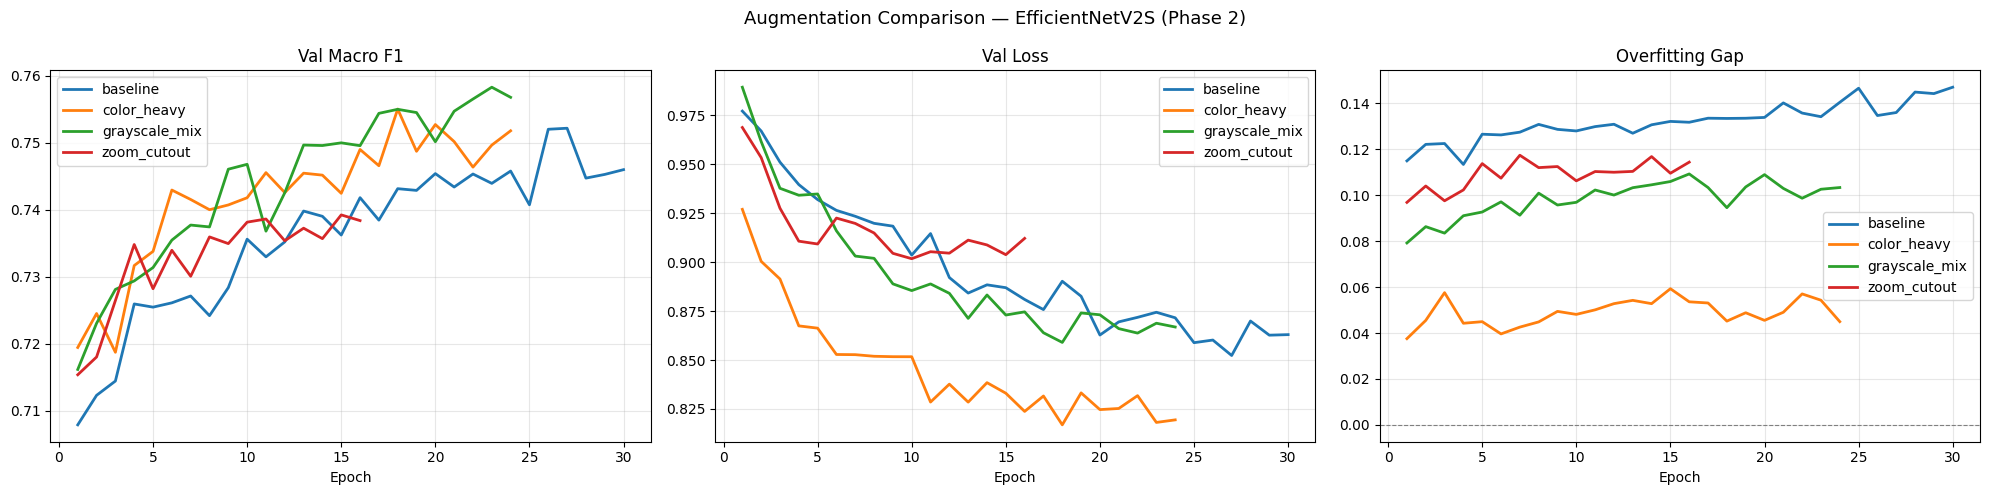

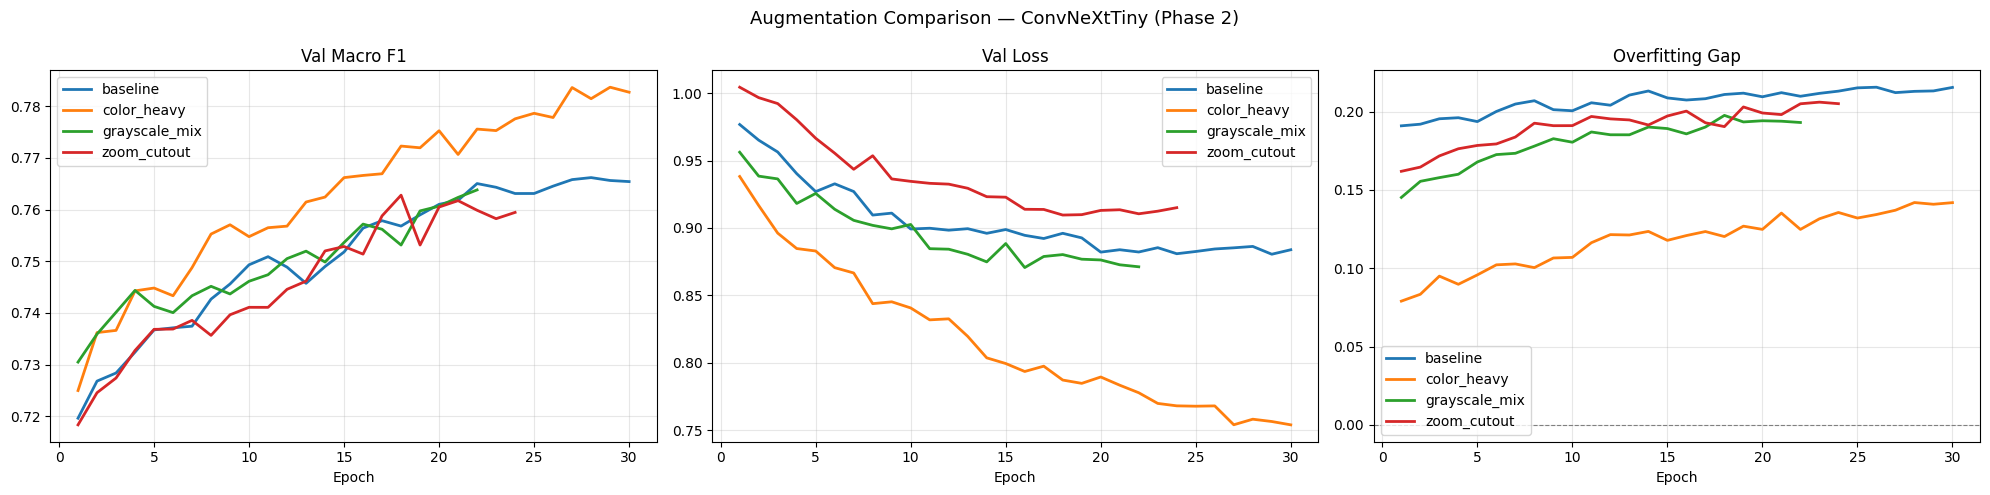

In [ ]:
for backbone_name in TOP2_BACKBONES:
    exps = {k: v for k, v in augmentation_results.items()
            if v['backbone'] == backbone_name}

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Augmentation Comparison — {backbone_name} (Phase 2)', fontsize=13)

    for exp_name, r in exps.items():
        hist  = r['p2_history']
        label = r['augmentation']
        epochs = range(1, len(hist['val_macro_f1']) + 1)
        gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]

        axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
        axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
        axes[2].plot(epochs, gap,                  label=label, linewidth=2)

    for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'aug_comparison_{backbone_name}.png'), dpi=150)
    plt.show()

## <font color='#2f94d7' size=6>**7.5 Experiment 5**</font> <a class="anchor" id="7_5"></a>

[Back to TOC](#toc)

In [ ]:
# Augmentation configs
AUGMENTATION_CONFIGS = {
    'color_heavy_geo': keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),        # adicionar geometria ligeira
    layers.RandomTranslation(0.04, 0.04),
    layers.RandomBrightness(0.35),
    layers.RandomContrast(0.35),
    layers.RandomSaturation(factor=(0.5, 1.5)),
    layers.RandomHue(0.08),
], name='aug_color_heavy_geo')
}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : color_heavy_geo
Unfreeze     : 30
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 290s 486ms/step - loss: 2.0957 - macro_f1: 0.3979 - top3_accuracy: 0.6507 - val_loss: 1.5109 - val_macro_f1: 0.5360 - val_top3_accuracy: 0.7851 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 172s 300ms/step - loss: 1.6085 - macro_f1: 0.5140 - top3_accuracy: 0.7629 - val_loss: 1.4119 - val_macro_f1: 0.5676 - val_top3_accuracy: 0.8141 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 172s 294ms/step - loss: 1.4427 - macro_f1: 0.5453 - top3_accuracy: 0.7947 - val_loss: 1.3298 - val_macro_f1: 0.5968 - val_top3_accuracy: 0.8346 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 170s 293ms/step - loss: 1.3487 - macro_f1: 0.5711 - top3_accuracy: 0.8129 - val_loss: 1.3171 - val_macro_f1: 0.6005 - val_top3_accuracy: 0.8261 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 171s 294ms/step - loss: 1.2773 - macro_f1: 0.58

In [ ]:
# RESULTS TABLE
print(f'{"Experiment":<35} {"P2 Val F1":>10} {"P2 Top-3":>10} {"P2 Val Loss":>12} {"Overfit":>10}')
print('-' * 82)

for name, r in sorted(augmentation_results.items(), key=lambda x: x[1]['p2_val_f1'], reverse=True):
    print(f'{name:<35} {r["p2_val_f1"]:>10.4f} {r["p2_val_top3"]:>10.4f} {r["p2_val_loss"]:>12.4f} {r["p2_overfit"]:>10.4f}')

Experiment                           P2 Val F1   P2 Top-3  P2 Val Loss    Overfit
----------------------------------------------------------------------------------
ConvNeXtTiny_color_heavy_geo            0.7237     0.9025       0.9730     0.1229
EfficientNetV2S_color_heavy_geo         0.7120     0.8921       0.9530     0.0380


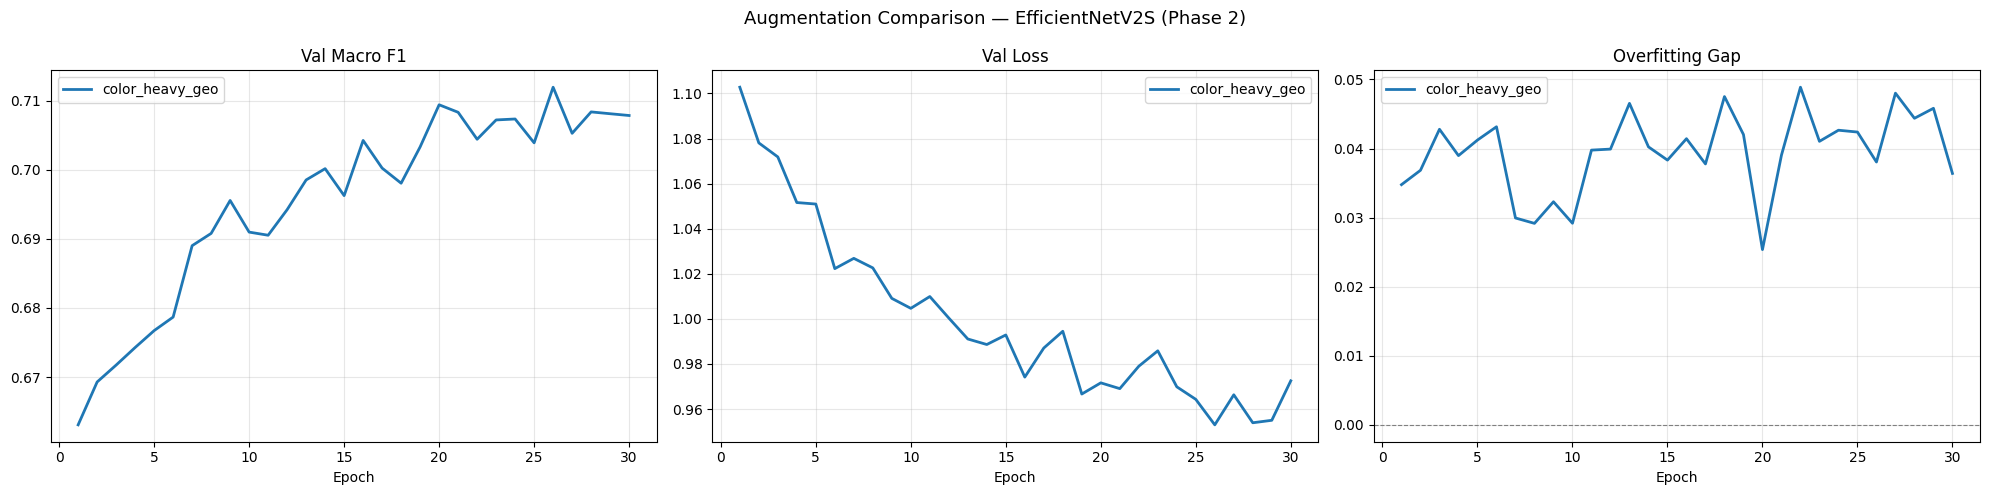

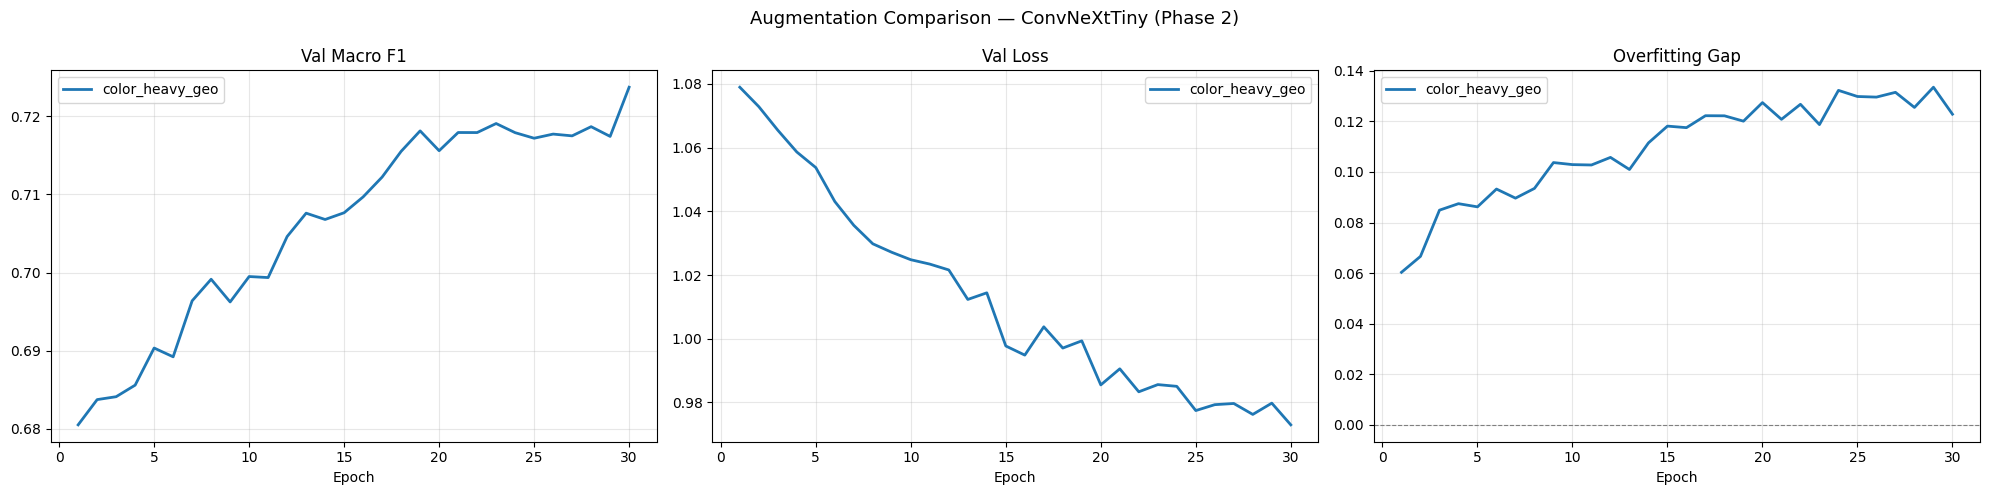

In [ ]:
for backbone_name in TOP2_BACKBONES:
    exps = {k: v for k, v in augmentation_results.items()
            if v['backbone'] == backbone_name}

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Augmentation Comparison — {backbone_name} (Phase 2)', fontsize=13)

    for exp_name, r in exps.items():
        hist  = r['p2_history']
        label = r['augmentation']
        epochs = range(1, len(hist['val_macro_f1']) + 1)
        gap = [tr - va for tr, va in zip(hist['macro_f1'], hist['val_macro_f1'])]

        axes[0].plot(epochs, hist['val_macro_f1'], label=label, linewidth=2)
        axes[1].plot(epochs, hist['val_loss'],     label=label, linewidth=2)
        axes[2].plot(epochs, gap,                  label=label, linewidth=2)

    for ax, title in zip(axes, ['Val Macro F1', 'Val Loss', 'Overfitting Gap']):
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'aug_comparison_{backbone_name}.png'), dpi=150)
    plt.show()

## <font color='#2f94d7' size=6>**7.6 Experiment 6**</font> <a class="anchor" id="7_6"></a>

[Back to TOC](#toc)

In [ ]:
# Augmentation configs
AUGMENTATION_CONFIGS = {
    'baseline': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_baseline'),

    'zoom': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomZoom((-0.15, 0.15)),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_zoom'),

    'cutout': keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.03),
        layers.RandomTranslation(0.03, 0.03),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
        layers.RandomErasing(
            factor=0.3,
            scale=(0.02, 0.2),
        ),
    ], name='aug_cutout'),
}

In [ ]:
# FULL COMPARISON LOOP
augmentation_results = {}

for backbone_name in TOP2_BACKBONES:
    cfg = BACKBONE_CONFIGS[backbone_name]
    n_unfreeze = UNFREEZE_CONFIG[backbone_name]

    for aug_name, augmentation_model in AUGMENTATION_CONFIGS.items():
        results = run_augmentation_experiment(
            train_raw=train_ds_raw,
            val_raw=val_ds_raw,
            backbone_name=backbone_name,
            cfg=cfg,
            backbone_configs=BACKBONE_CONFIGS,
            aug_name=aug_name,
            augmentation_model=augmentation_model,
            n_unfreeze=n_unfreeze,
            num_classes=NUM_CLASSES,
            AUTOTUNE=AUTOTUNE,
            batch_size=BATCH_SIZE,
            seed=SEED,
            class_weight_dict=class_weight_dict,
            make_metrics=make_metrics,
            phase1_config=PHASE1_CONFIG,
            phase2_config=PHASE2_CONFIG
        )

        augmentation_results[f'{backbone_name}_{aug_name}'] = results

        print(f'Best P2 Val Macro F1 : {results["p2_val_f1"]:.4f}')
        print(f'Best P2 Val Top-3    : {results["p2_val_top3"]:.4f}')
        print(f'Min P2 Val Loss      : {results["p2_val_loss"]:.4f}')
        print(f'P2 Overfit Gap       : {results["p2_overfit"]:.4f}')


Backbone     : EfficientNetV2S
Augmentation : baseline
Unfreeze     : 30
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 828s 2s/step - loss: 1.7797 - macro_f1: 0.4806 - top3_accuracy: 0.7214 - val_loss: 1.2633 - val_macro_f1: 0.5993 - val_top3_accuracy: 0.8386 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 551s 2s/step - loss: 1.1957 - macro_f1: 0.6296 - top3_accuracy: 0.8421 - val_loss: 1.1743 - val_macro_f1: 0.6327 - val_top3_accuracy: 0.8566 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 544s 2s/step - loss: 1.0374 - macro_f1: 0.6631 - top3_accuracy: 0.8750 - val_loss: 1.0790 - val_macro_f1: 0.6597 - val_top3_accuracy: 0.8656 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - loss: 0.9077 - macro_f1: 0.6986 - top3_accuracy: 0.8946 - val_loss: 1.0745 - val_macro_f1: 0.6570 - val_top3_accuracy: 0.8711 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - loss: 0.8536 - macro_f1: 0.7108 - top3_accuracy: 0.